# 02 — Unmixing pipeline

Noise estimation → HySime subspace dimension → MVSA endmember extraction →
SUNSAL abundance estimation, with diagnostics. This is the notebook version of
`scripts/run_pipeline.py` (which is what the Streamlit app consumes).
Replaces `analysis_elections_2025`.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config

sns.set_style('whitegrid')
config = load_config()

In [2]:
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.unmixing import est_noise, hysime, mvsa, sunsal_mod

rng = np.random.seed(config['unmixing'].getint('seed'))

df = load_complete(config)
pre = preprocess_from_config(df, config)
Y = pre.Y
L, N = Y.shape

candidates: 66 -> 42 (25th pct >= 10.0)
precincts:  92,488 -> 92,486 (total votes >= 10.0)
Y: 42 candidates x 92,486 precincts (valid_ballots normalization)


## Noise estimation + HySime

HySime signal subspace dimension kf = 6


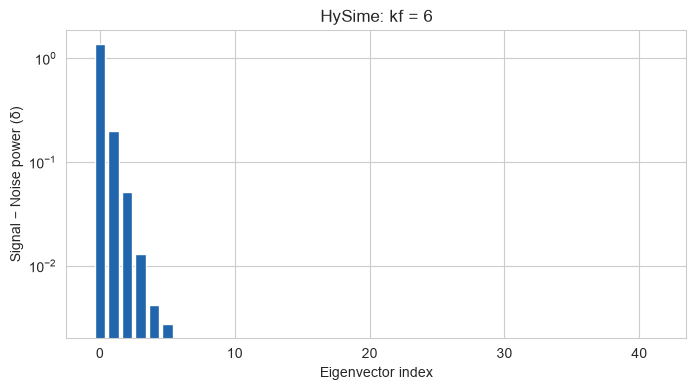

In [3]:
w_hat, Rw_hat = est_noise(Y, noise_type='additive', verbose=False)
kf, Ek, E, delta_p = hysime(Y, w_hat, Rw_hat, verbose=False)
print(f'HySime signal subspace dimension kf = {kf}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(delta_p)), delta_p,
       color=['#2166ac' if d > 0 else '#d1e5f0' for d in delta_p])
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Eigenvector index')
ax.set_ylabel('Signal − Noise power (δ)')
ax.set_yscale('log')
ax.set_title(f'HySime: kf = {kf}');

## MVSA endmember extraction

In [4]:
n_archetypes = config['unmixing'].getint('n_archetypes') or kf
print(f'n_archetypes = {n_archetypes}')

endm, Sest, Up, my, sing_values = mvsa(
    Y, p=n_archetypes,
    MM_iters=config['unmixing'].getint('mvsa_mm_iters'),
    spherize='yes', verbose=1)
endm.shape

n_archetypes = 7
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


  iter 1: f0 = 19.6996, f = 15.6600


  iter 2: f0 = 15.6600, f = 14.6776


  iter 3: f0 = 14.6776, f = 14.5344
  iter 3: termination test PASSED


(42, 7)

## SUNSAL abundance estimation (positivity + sum-to-one)

In [5]:
abundances, res_p, res_d = sunsal_mod(
    endm, Y, positivity='yes', addone='yes',
    AL_iters=config['unmixing'].getint('sunsal_al_iters'),
    lambda_=0.0, tol=config['unmixing'].getfloat('sunsal_tol'), verbose='no')

neg_frac = np.mean(abundances < -1e-6)
sum_dev = np.abs(abundances.sum(axis=0) - 1.0)
print(f'abundances: {abundances.shape}')
print(f'fraction negative: {neg_frac:.6f}')
print(f'|sum-1| mean {sum_dev.mean():.2e}, max {sum_dev.max():.2e}')

abundances: (7, 92486)
fraction negative: 0.000000
|sum-1| mean 3.59e-07, max 9.59e-03


## Reconstruction quality

In [6]:
Y_rec = endm @ abundances
rss = np.sum((Y - Y_rec) ** 2)
rmse = np.sqrt(np.mean((Y - Y_rec) ** 2))
print(f'RSS:  {rss:.4f}')
print(f'RMSE: {rmse:.6f}')

RSS:  5848.2442
RMSE: 0.038802


## Save for the app / plot notebooks

Writes `data/processed/{endmembers.csv, abundances.parquet, meta.json}` —
the same artifacts as `scripts/run_pipeline.py`.

In [7]:
from src.data.loading import save_processed

meta = {
    'preprocessing': pre.params,
    'hysime_kf': int(kf),
    'n_archetypes': int(n_archetypes),
    'seed': config['unmixing'].getint('seed'),
    'rmse': float(rmse),
    'candidate_labels': pre.candidate_labels,
}
save_processed(pre, endm, abundances, meta, config)

PosixPath('/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/data/processed')